# Gold's Loud Cousin — a quantitative teardown \U0001F52C
### Rolling and regime betas · residual factor hunt · β(β−1)σ²/2 · a financed replication

![Signal: Busted](https://img.shields.io/badge/Signal-Busted-c0392b?style=flat-square)
![Tradability: Useful](https://img.shields.io/badge/Tradability-Useful-2ea44f?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). Three separate
questions get collapsed into one in most versions of this argument: whether the beta is stable,
whether the residual is an asset, and whether the replication survives contact with financing
and volatility drag.

> ⚠️ **Not investment advice.** Total-return closes from Yahoo! Finance pinned as-of the date in
> [`docs/results.md`](../docs/results.md).
>
> \U0001F4A1 **The `\U0001F4A1 In plain words` notes** translate each result back into intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))   # repo root (quantlab/ lives there)
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

In [2]:
from loudcousin import data, strategy as st

px = data.load_prices()
rets = px.pct_change()
common = rets[[data.GOLD, data.SILVER, data.DOLLAR, data.TIPS, data.INDUSTRIAL,
               data.CASH]].dropna()
g, s = common[data.GOLD], common[data.SILVER]
b = st.full_sample_beta(s, g)
print(f"as-of {data.AS_OF} | {len(common):,} sessions, "
      f"{common.index[0].date()} -> {common.index[-1].date()}")
print(f"gold vol {g.std() * np.sqrt(252):.1%}   silver vol {s.std() * np.sqrt(252):.1%}")
print(f"silver = {b['alpha_ann']:+.2%}/yr + {b['beta']:.3f} x gold   R2 {b['r2']:.1%}")

as-of 2026-06-30 | 4,801 sessions, 2007-05-31 -> 2026-06-30
gold vol 18.1%   silver vol 33.2%
silver = -2.60%/yr + 1.446 x gold   R2 62.5%


## Verdict, up front

| Axis | Stamp | Why |
|---|---|---|
| **Signal** | Busted | Regressed on gold over 4,801 sessions, silver's beta is **1.45** (±0.03) with an R² of 62% — so about 38% of silver's variance is *not* gold. That leftover is not noise. Its annualised volatility is 20.3%, and it loads on outside factors with a largest |*t*| of **10.58** (on industrial). Nor is the beta a constant: over rolling one-year windows it ranges 0.94 to 2.15, a spread of **86% of its own mean**, and it is 1.29 on gold's up days against 1.57 on its down days. 'Silver is levered gold' is a reasonable first approximation and a poor second one. |
| **Tradability** | Useful | Holding a 1.45× daily-rebalanced gold position instead of silver, financed at cash plus 0.5%, tracked it with a correlation of 0.79 and an annualised tracking error of **20.3%** — which is not tracking, it is a different asset. Over 19 years silver compounded at +7.7% against the replica's +11.9% (Sharpe 0.39 vs 0.56). Part of that gap is pure arithmetic: levering a 18%-vol asset 1.45× costs about **1.1% a year** in volatility drag, before financing and before costs. |

> \U0001F4A1 **In plain words.** Silver is levered gold in roughly the sense that a dog is a
> levered cat: correlated, similar in outline, and not a substitute.

## 1 · Hypotheses

- **H₁ (the folklore).** `silver = β × gold + ε` with β constant and ε white noise.
- **H₂ (stability).** β's rolling range is small relative to β.
- **H₃ (residual).** ε loads on nothing observable — not the dollar, not real rates, not
  industrial activity.
- **H₄ (replication).** A financed β× gold position tracks silver closely enough to substitute
  for it, after the `β(β−1)σ²/2` drag.

## 2 · The teardown

### 2.1 Beta, four windows and five regimes

           n   mean     sd    min    max    p10    p90  range_over_mean
window                                                                 
63      4738 1.4450 0.3580 0.5420 3.1520 1.0870 1.8410           1.8060
126     4675 1.4300 0.2930 0.6960 2.7110 1.1350 1.7910           1.4090
252     4549 1.4210 0.2150 0.9380 2.1540 1.1590 1.7270           0.8560
756     4045 1.4330 0.1460 1.1960 1.7060 1.2250 1.5970           0.3560



                   n   beta     se     r2
regime                                   
gold up days    2539 1.2850 0.0430 0.3940
gold down days  2262 1.5720 0.0910 0.5110
gold vol Q1     1580 1.4160 0.0450 0.6150
gold vol Q2     1579 1.4570 0.0430 0.6120
gold vol Q3     1579 1.4470 0.0570 0.6330


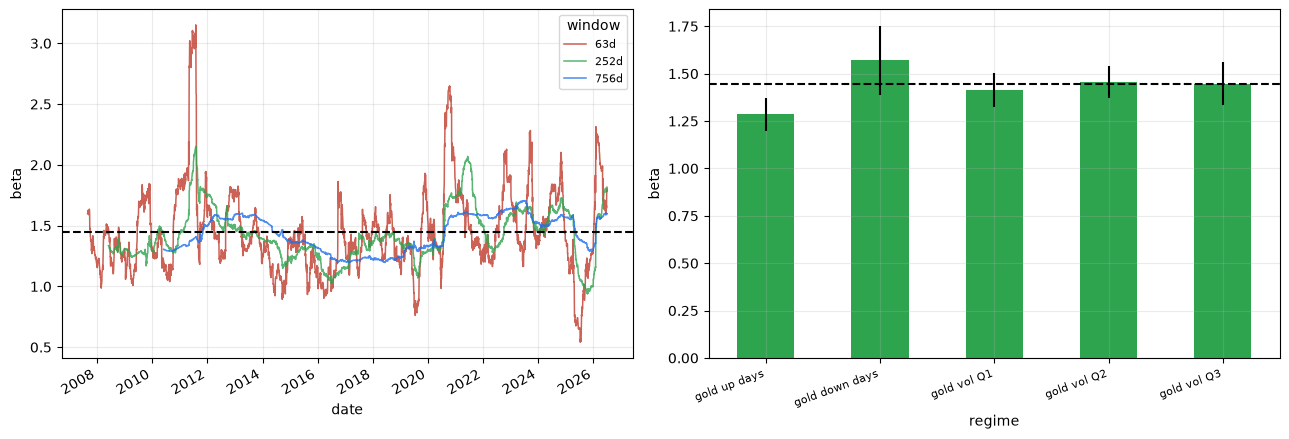

In [3]:
print(st.rolling_beta_table(s, g).round(3).to_string())
print()
print(st.beta_by_regime(s, g).round(3).to_string())
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for w, c in zip((63, 252, 756), ("#c0392b", "#2ea44f", "#1f6feb")):
    st.rolling_beta(s, g, w).dropna().plot(ax=axes[0], lw=1.1, color=c, label=f"{w}d",
                                           alpha=0.8)
axes[0].axhline(b["beta"], color="k", ls="--", lw=1.5)
axes[0].set_ylabel("beta"); axes[0].legend(fontsize=8, title="window")
reg = st.beta_by_regime(s, g)
reg["beta"].plot.bar(ax=axes[1], color="#2ea44f", yerr=reg["se"] * 2)
axes[1].axhline(b["beta"], color="k", ls="--", lw=1.5)
axes[1].set_ylabel("beta"); plt.setp(axes[1].get_xticklabels(), rotation=20, ha="right",
                                     fontsize=8)
plt.tight_layout(); plt.show()

### 2.2 The residual, diagnosed

n                     4,549.0000
mean_ann                 -0.0085
vol_ann                   0.2068
sharpe                   -0.0409
t_mean                   -0.1736
autocorr_1               -0.0090
autocorr_5               -0.0111
skew                     -0.6754
kurtosis                 13.4843
share_of_silver_vol          NaN


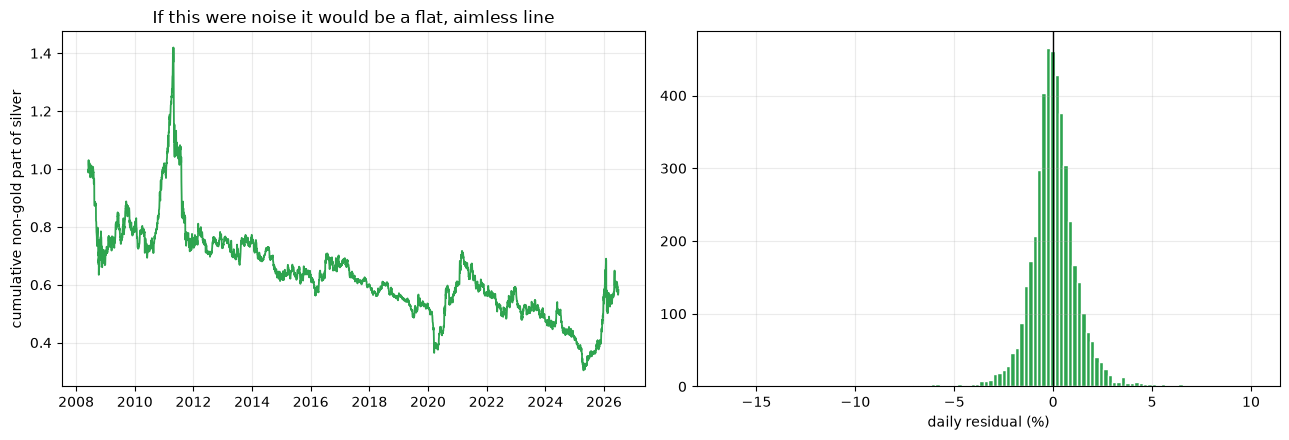

In [4]:
resid = st.residuals(s, g)
print(pd.Series(st.residual_diagnostics(resid)).round(4).to_string())
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(resid.index, (1 + resid).cumprod(), lw=1.3, color="#2ea44f")
axes[0].set_ylabel("cumulative non-gold part of silver")
axes[0].set_title("If this were noise it would be a flat, aimless line")
axes[1].hist(resid * 100, bins=120, color="#2ea44f", edgecolor="white")
axes[1].axvline(0, color="k", lw=1)
axes[1].set_xlabel("daily residual (%)")
plt.tight_layout(); plt.show()

### 2.3 Does it load on anything?

In [5]:
factors = pd.DataFrame({"dollar": common[data.DOLLAR],
                        "real_rates": common[data.TIPS],
                        "industrial": common[data.INDUSTRIAL]})
if data.COPPER in rets.columns and rets[data.COPPER].notna().sum() > 1000:
    factors["copper"] = rets[data.COPPER]
load = st.residual_loadings(resid, factors.reindex(resid.index))
print(load.round(4).to_string())

                       n    beta       t     r2
factor                                         
dollar              4549 -0.3428 -5.4435 0.0174
real_rates          4549 -0.1044 -1.4065 0.0010
industrial          4549  0.2577 10.5848 0.0735
copper              3674  0.1294  4.3427 0.0479
dollar (joint)      3674 -0.0544 -0.6766 0.0770
real_rates (joint)  3674 -0.1017 -1.3503 0.0770
industrial (joint)  3674  0.1726  5.5984 0.0770
copper (joint)      3674  0.1015  3.8922 0.0770


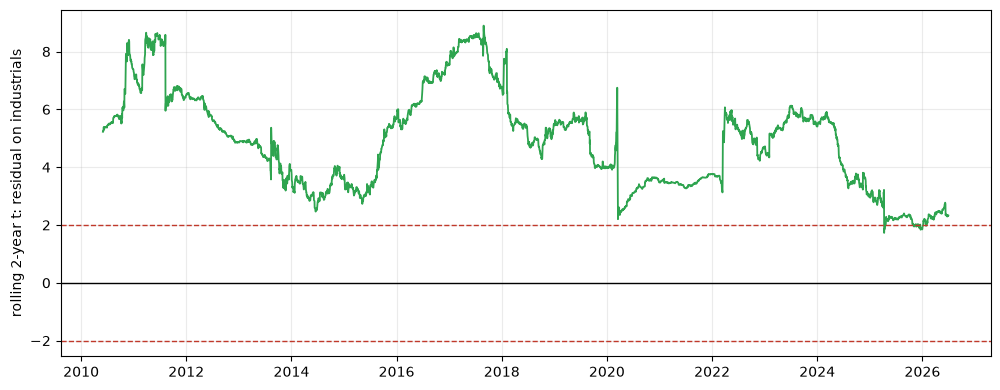

In [6]:
# the same question through time, since silver's industrial share has grown a lot
ind = common[data.INDUSTRIAL]
roll = pd.Series(
    [st.full_sample_beta(resid.iloc[i - 504:i],
                         ind.reindex(resid.index).iloc[i - 504:i]).get("t_vs_zero", np.nan)
     if i >= 504 else np.nan for i in range(len(resid))], index=resid.index)
fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(roll.index, roll, lw=1.3, color="#2ea44f")
ax.axhline(0, color="k", lw=1)
for y in (-2, 2):
    ax.axhline(y, ls="--", color="#c0392b", lw=1)
ax.set_ylabel("rolling 2-year t: residual on industrials")
plt.show()

> \U0001F4A1 **In plain words.** Photovoltaic demand went from negligible to about a fifth of
> silver consumption across this sample. If the industrial loading strengthens over time, that
> is the most likely reason — and it means the "levered gold" description was more accurate
> twenty years ago than it is now.

### 2.4 Volatility drag, in closed form and in the data

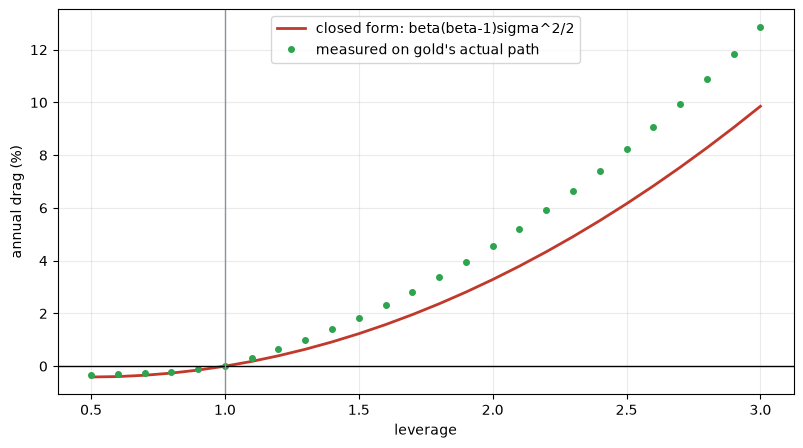

In [7]:
gv = g.std() * np.sqrt(252)
betas = np.linspace(0.5, 3.0, 26)
predicted = [st.leverage_drag(bb, gv) for bb in betas]
actual = []
for bb in betas:
    lev = st.levered_position(g, bb, common[data.CASH], financing_spread=0.0, cost_bps=0.0)
    yrs = len(lev) / 252
    realised = (1 + lev).prod() ** (1 / yrs) - 1
    naive = bb * ((1 + g).prod() ** (1 / yrs) - 1)
    actual.append(naive - realised)
fig, ax = plt.subplots(figsize=(9.5, 5))
ax.plot(betas, np.array(predicted) * 100, lw=2, color="#c0392b",
        label="closed form: beta(beta-1)sigma^2/2")
ax.plot(betas, np.array(actual) * 100, "o", ms=4, color="#2ea44f",
        label="measured on gold's actual path")
ax.axhline(0, color="k", lw=1); ax.axvline(1, color="#8b949e", lw=1)
ax.set_xlabel("leverage"); ax.set_ylabel("annual drag (%)"); ax.legend()
plt.show()

### 2.5 The replication, swept over leverage and financing

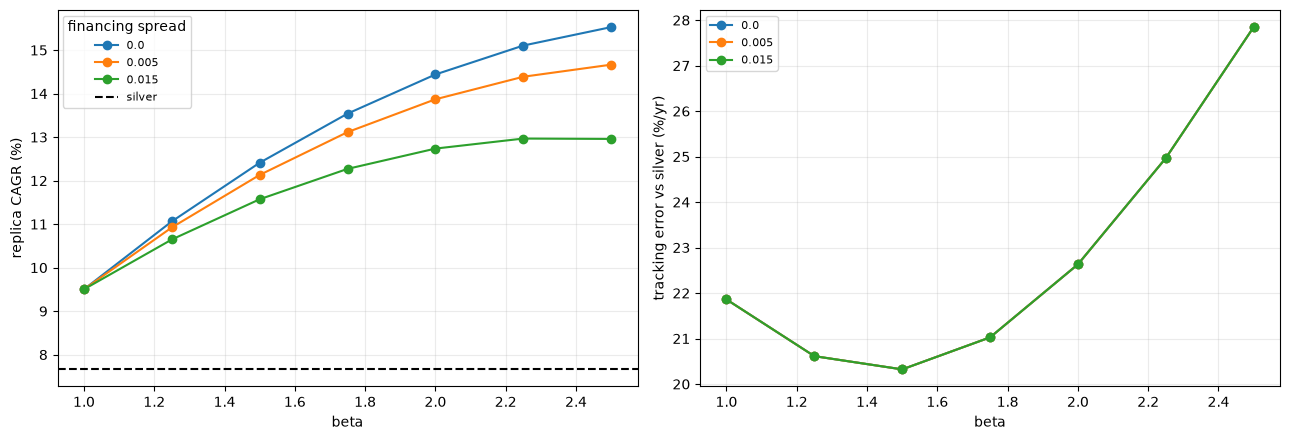

'  beta  financing   cagr  sharpe     te   corr\n1.0000     0.0000 0.0950  0.5918 0.2186 0.7903\n1.0000     0.0050 0.0950  0.5918 0.2186 0.7903\n1.0000     0.0150 0.0950  0.5918 0.2186 0.7903\n1.2500     0.0000 0.1106  0.5769 0.2061 0.7905\n1.2500     0.0050 0.1092  0.5714 0.2061 0.7905\n1.2500     0.0150 0.1065  0.5604 0.2061 0.7905\n1.5000     0.0000 0.1241  0.5670 0.2032 0.7906\n1.5000     0.0050 0.1213  0.5578 0.2032 0.7906\n1.5000     0.0150 0.1157  0.5394 0.2032 0.7906\n1.7500     0.0000 0.1354  0.5599 0.2103 0.7907\n1.7500     0.0050 0.1312  0.5481 0.2103 0.7907\n1.7500     0.0150 0.1227  0.5244 0.2103 0.7907\n2.0000     0.0000 0.1444  0.5546 0.2263 0.7908\n2.0000     0.0050 0.1387  0.5408 0.2263 0.7908\n2.0000     0.0150 0.1274  0.5132 0.2263 0.7908\n2.2500     0.0000 0.1510  0.5504 0.2497 0.7908\n2.2500     0.0050 0.1439  0.5351 0.2497 0.7908\n2.2500     0.0150 0.1297  0.5044 0.2497 0.7908\n2.5000     0.0000 0.1553  0.5471 0.2785 0.7908\n2.5000     0.0050 0.1467  0.5306 0.2785

In [8]:
rows = []
for beta in (1.0, 1.25, 1.5, 1.75, 2.0, 2.25, 2.5):
    for fin in (0.0, 0.005, 0.015):
        r = st.replication_backtest(s, g, common[data.CASH], beta=beta,
                                    financing_spread=fin, cost_bps=1.0)
        rows.append({"beta": beta, "financing": fin, "cagr": r["replica"]["cagr"],
                     "sharpe": r["replica"]["sharpe"], "te": r["tracking_error_ann"],
                     "corr": r["correlation"]})
d = pd.DataFrame(rows)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
d.pivot(index="beta", columns="financing", values="cagr").mul(100).plot(ax=axes[0], marker="o")
rep = st.replication_backtest(s, g, common[data.CASH], financing_spread=0.005, cost_bps=1.0)
axes[0].axhline(rep["silver"]["cagr"] * 100, color="k", ls="--", lw=1.5, label="silver")
axes[0].set_ylabel("replica CAGR (%)"); axes[0].legend(fontsize=8, title="financing spread")
d.pivot(index="beta", columns="financing", values="te").mul(100).plot(ax=axes[1], marker="o")
axes[1].set_ylabel("tracking error vs silver (%/yr)"); axes[1].legend(fontsize=8, title="")
plt.tight_layout(); plt.show()
d.round(4).to_string(index=False)

### 2.6 The ratio trade

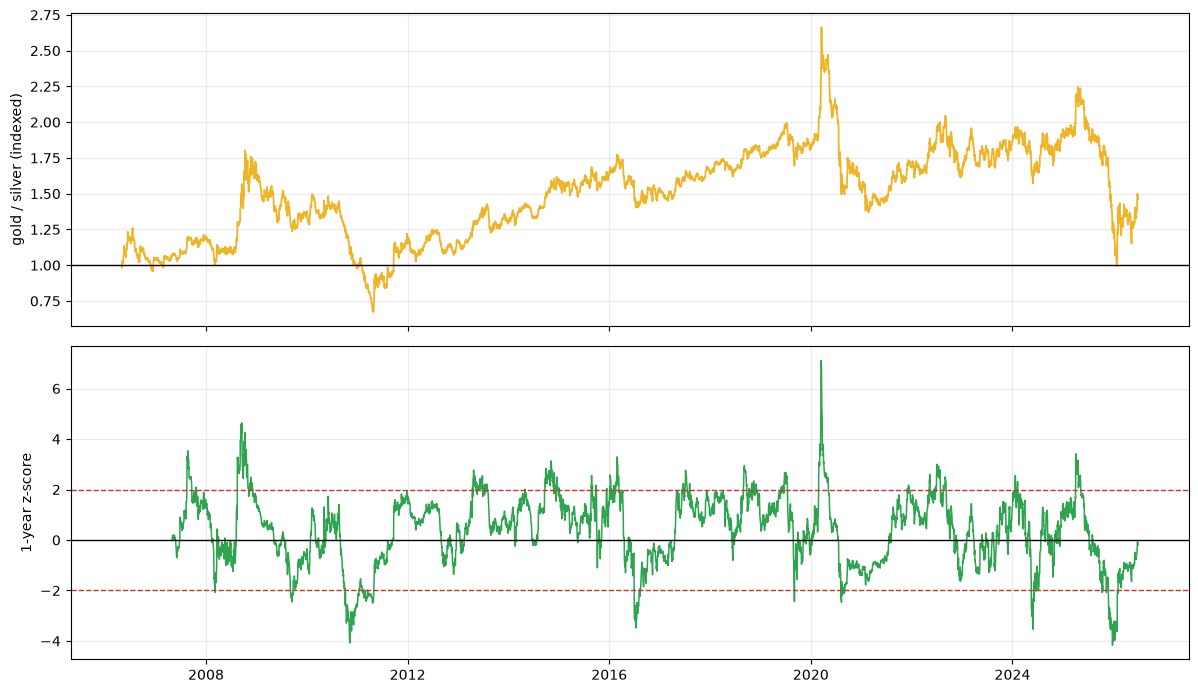

            n   slope       t     r2
horizon                             
21       4802 -0.0000 -0.0065 0.0000
63       4760 -0.0070 -0.8742 0.0077
126      4697 -0.0209 -1.4292 0.0338
252      4571 -0.0393 -2.7845 0.0733


In [9]:
ratio = st.gold_silver_ratio(px[data.GOLD], px[data.SILVER])
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
axes[0].plot(ratio.index, ratio, lw=1.3, color="#f0b429")
axes[0].axhline(1.0, color="k", lw=1)
axes[0].set_ylabel("gold / silver (indexed)")
z = ((np.log(ratio) - np.log(ratio).rolling(252).mean())
     / np.log(ratio).rolling(252).std())
axes[1].plot(z.index, z, lw=1.1, color="#2ea44f")
for y in (-2, 0, 2):
    axes[1].axhline(y, color="k" if y == 0 else "#c0392b", lw=1,
                    ls="-" if y == 0 else "--")
axes[1].set_ylabel("1-year z-score")
plt.tight_layout(); plt.show()
print(st.ratio_mean_reversion(ratio).round(4).to_string())

### 2.7 The synthetic control

In [10]:
rows = []
for tag, kw in (("silver IS levered gold", {}),
                ("+ industrial driver", {"industrial_load": 1.5}),
                ("+ drifting beta", {"beta_drift": 0.8}),
                ("both", {"industrial_load": 1.5, "beta_drift": 0.8})):
    sw = st.synthetic_world(n=6000, true_beta=1.8, **kw)
    rr = st.residuals(sw["silver"], sw["gold"])
    lt = st.residual_loadings(rr, sw[["industrial"]])
    rb = st.rolling_beta_table(sw["silver"], sw["gold"], windows=(252,))
    rows.append({"world": tag, "residual t on industrial": lt.loc["industrial", "t"],
                 "beta range / mean": rb.loc[252, "range_over_mean"],
                 "R2 of silver on gold": st.full_sample_beta(sw["silver"], sw["gold"])["r2"]})
d = pd.DataFrame(rows).set_index("world")
print(d.round(3).to_string())
print(f"\nfor comparison, the real tape: residual t "
      f"{load['t'].abs().max():.2f}, beta range/mean "
      f"{st.rolling_beta_table(s, g, windows=(252,)).loc[252, 'range_over_mean']:.2f}, "
      f"R2 {b['r2']:.2f}")

                        residual t on industrial  beta range / mean  R2 of silver on gold
world                                                                                    
silver IS levered gold                   -0.2000             0.1860                0.6990
+ industrial driver                     102.9710             0.4040                0.4470
+ drifting beta                          -0.1480             0.9750                0.6510
both                                    101.3790             1.1990                0.4250

for comparison, the real tape: residual t 10.58, beta range/mean 0.86, R2 0.62


## 3 · The verdict

In [11]:
rep = st.replication_backtest(s, g, common[data.CASH], financing_spread=0.005,
                              cost_bps=1.0)
rbt = st.rolling_beta_table(s, g, windows=(252,))
uni = load[~load.index.str.contains(r"\(joint\)")]
pd.DataFrame({
    "beta of silver on gold": [b["beta"]],
    "R2": [b["r2"]],
    "residual vol (ann)": [b["resid_vol_ann"]],
    "rolling beta min": [rbt.loc[252, "min"]],
    "rolling beta max": [rbt.loc[252, "max"]],
    "largest residual |t|": [uni["t"].abs().max()],
    "replication correlation": [rep["correlation"]],
    "replication tracking error": [rep["tracking_error_ann"]],
    "predicted volatility drag": [rep["predicted_drag"]],
}).T.rename(columns={0: "value"}).round(4)

,value
beta of silver on gold,1.4457
R2,0.6246
residual vol (ann),0.2031
rolling beta min,0.9377
rolling beta max,2.1538
largest residual |t|,10.5848
replication correlation,0.7906
replication tracking error,0.2030
predicted volatility drag,0.0106


## 4 · Going further

- **Physical demand.** The single biggest missing variable. Silver's industrial share, and
  photovoltaics inside it, moved enormously across this sample and no price series contains it.
- **Cointegration, not just beta.** Escribano & Granger (1998) treat the two metals as
  cointegrated with a slowly-moving relationship; an error-correction model would handle the
  drifting beta properly rather than describing it.
- **Rebalancing frequency.** Daily is the worst case for drag. Monthly, or a buy-and-hold
  levered position, would be the fairer replication and would narrow the gap.
- **Asymmetric betas properly.** Section 2.1 splits on the sign of gold's move, which is a crude
  version of what Ang & Chen (2002) do with exceedance correlations.